# The Shor $[[9,1,3]]$ Code

## 1. Introduction
The Shor code, introduced by Peter Shor in 1995, was the first quantum error-correcting code to demonstrate that a single logical qubit could be protected against arbitrary single-qubit errors (Bit-Flip $X$, Phase-Flip $Z$, or combined $Y$). It is a **concatenated code** that combines the properties of the 3-qubit bit-flip code and the 3-qubit phase-flip code.

### 1.1 Construction Principle
The code works by nesting two levels of encoding:

1.  **Outer Layer (Phase Protection):** The logical qubit is first encoded using a 3-qubit phase-flip code.
    $$|0\rangle \to |+++\rangle, \quad |1\rangle \to |---\rangle$$
2.  **Inner Layer (Bit Protection):** Each of those 3 qubits is then encoded into a 3-qubit bit-flip code.
    $$|+\rangle \to \frac{1}{\sqrt{2}}(|000\rangle + |111\rangle)$$
    $$|-\rangle \to \frac{1}{\sqrt{2}}(|000\rangle - |111\rangle)$$



### 1.2 Logical States
The resulting 9-qubit logical basis states are entangled GHZ-like states:

$$|0\rangle_L = \frac{1}{2\sqrt{2}} \left( (|000\rangle + |111\rangle) \otimes (|000\rangle + |111\rangle) \otimes (|000\rangle + |111\rangle) \right)$$

$$|1\rangle_L = \frac{1}{2\sqrt{2}} \left( (|000\rangle - |111\rangle) \otimes (|000\rangle - |111\rangle) \otimes (|000\rangle - |111\rangle) \right)$$

---

## 2. Mathematical Formalism: Stabilizers

The Shor code is a **Stabilizer Code** with parameters $[[9, 1, 3]]$. It encodes $k=1$ logical qubit into $n=9$ physical qubits and has a distance $d=3$, meaning it can correct $\lfloor (d-1)/2 \rfloor = 1$ error.

It uses $n-k = 8$ stabilizer generators to detect errors. These generators allow us to identify the error syndrome without collapsing the logical state.

### 2.1 The Generator Matrix
We define the 8 generators $\{g_1, \dots, g_8\}$.
* **$Z$-type generators** detect Bit-Flip ($X$) errors within each block of 3.
* **$X$-type generators** detect Phase-Flip ($Z$) errors between blocks.

| Generator | Operator | Function |
| :--- | :--- | :--- |
| $g_1$ | $Z_0 Z_1$ | Detects bit-flip in Block 1 (qubit 0 vs 1) |
| $g_2$ | $Z_1 Z_2$ | Detects bit-flip in Block 1 (qubit 1 vs 2) |
| $g_3$ | $Z_3 Z_4$ | Detects bit-flip in Block 2 |
| $g_4$ | $Z_4 Z_5$ | Detects bit-flip in Block 2 |
| $g_5$ | $Z_6 Z_7$ | Detects bit-flip in Block 3 |
| $g_6$ | $Z_7 Z_8$ | Detects bit-flip in Block 3 |
| $g_7$ | $X_0 X_1 X_2 X_3 X_4 X_5$ | Compares Phase of Block 1 vs Block 2 |
| $g_8$ | $X_3 X_4 X_5 X_6 X_7 X_8$ | Compares Phase of Block 2 vs Block 3 |

### 2.2 Syndrome Logic table
When we measure these stabilizers using ancilla qubits, we get eigenvalues $\pm 1$ (mapped to bits 0 and 1).

**Bit-Flip Logic (Per Block):**
Each block has two parity bits ($s_1, s_2$) derived from the Z-stabilizers.
* `00`: No $X$ error.
* `01`: Error on Qubit 0 (Left).
* `10`: Error on Qubit 2 (Right).
* `11`: Error on Qubit 1 (Middle).

**Phase-Flip Logic (Global):**
We have two phase bits ($p_1, p_2$) derived from the X-stabilizers ($g_7, g_8$).
* `00`: No $Z$ error.
* `01`: Phase flip on Block 1.
* `10`: Phase flip on Block 3.
* `11`: Phase flip on Block 2.

In [1]:
%pip install numpy==1.26.4 scipy==1.12.0

import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib as plt
from scipy.optimize import fsolve

print("Imports successful")


Note: you may need to restart the kernel to use updated packages.
Imports successful


In [2]:
class ShorCode:
    def __init__(self):
        # 9 Data Qubits
        self.qr_data = QuantumRegister(9, name='data')
        # 8 Ancilla Qubits
        self.qr_anc = QuantumRegister(8, name='anc')

        # Classical Registers for Syndromes
        self.cr_z1 = ClassicalRegister(2, name='syn_z1') # Block 1
        self.cr_z2 = ClassicalRegister(2, name='syn_z2') # Block 2
        self.cr_z3 = ClassicalRegister(2, name='syn_z3') # Block 3
        self.cr_x  = ClassicalRegister(2, name='syn_x')  # Phase

        # Final readout
        self.cr_out = ClassicalRegister(9, name='readout')

        # Initialize Circuit
        self.qc = QuantumCircuit(
            self.qr_data, self.qr_anc,
            self.cr_z1, self.cr_z2, self.cr_z3, self.cr_x, self.cr_out
        )

    def encode(self):
        """
        Encodes a single logical |0> into the 9-qubit Shor state
        """
        # Phase-flip protection (Outer Layer) -> |+++>
        self.qc.cx(self.qr_data[0], self.qr_data[3])
        self.qc.cx(self.qr_data[0], self.qr_data[6])
        self.qc.h(self.qr_data[0])
        self.qc.h(self.qr_data[3])
        self.qc.h(self.qr_data[6])

        # Bit-flip protection (Inner Layer) -> GHZ states
        # Block 1
        self.qc.cx(self.qr_data[0], self.qr_data[1])
        self.qc.cx(self.qr_data[0], self.qr_data[2])
        # Block 2
        self.qc.cx(self.qr_data[3], self.qr_data[4])
        self.qc.cx(self.qr_data[3], self.qr_data[5])
        # Block 3
        self.qc.cx(self.qr_data[6], self.qr_data[7])
        self.qc.cx(self.qr_data[6], self.qr_data[8])

        self.qc.barrier(label='Encoding Done')

    def inject_error(self, error_type, qubit_index):
        """
        Injects a specific error for testing
        error_type: 'X', 'Y', or 'Z
        """
        if error_type == 'X':
            self.qc.x(self.qr_data[qubit_index])
        elif error_type == 'Z':
            self.qc.z(self.qr_data[qubit_index])
        elif error_type == 'Y':
            self.qc.y(self.qr_data[qubit_index])

        self.qc.barrier(label=f'Error {error_type}_{qubit_index}')

    def measure_syndromes(self):
        """
        Non-destructive measurement of the 8 stabilizers using ancillas
        """
        # Z-Stabilizers (Bit Flips)
        # Check parity of neighbors (q0-q1, q1-q2, etc.)
        # Logic - CNOT(data -> ancilla)

        # Block 1 (Ancillas 0, 1)
        self.qc.cx(self.qr_data[0], self.qr_anc[0])
        self.qc.cx(self.qr_data[1], self.qr_anc[0])
        self.qc.cx(self.qr_data[1], self.qr_anc[1])
        self.qc.cx(self.qr_data[2], self.qr_anc[1])

        # Block 2 (Ancillas 2, 3)
        self.qc.cx(self.qr_data[3], self.qr_anc[2])
        self.qc.cx(self.qr_data[4], self.qr_anc[2])
        self.qc.cx(self.qr_data[4], self.qr_anc[3])
        self.qc.cx(self.qr_data[5], self.qr_anc[3])

        # Block 3 (Ancillas 4, 5)
        self.qc.cx(self.qr_data[6], self.qr_anc[4])
        self.qc.cx(self.qr_data[7], self.qr_anc[4])
        self.qc.cx(self.qr_data[7], self.qr_anc[5])
        self.qc.cx(self.qr_data[8], self.qr_anc[5])

        # X-Stabilizers (Phase Flips)
        # Logic: Hadamard(anc) -> CNOT(anc -> data) -> Hadamard(anc)
        self.qc.h(self.qr_anc[6])
        self.qc.h(self.qr_anc[7])

        # Ancilla 6 checks Block 1 vs Block 2 (X0...X5)
        for i in range(0, 6):
            self.qc.cx(self.qr_anc[6], self.qr_data[i])

        # Ancilla 7 checks Block 2 vs Block 3 (X3...X8)
        for i in range(3, 9):
            self.qc.cx(self.qr_anc[7], self.qr_data[i])

        self.qc.h(self.qr_anc[6])
        self.qc.h(self.qr_anc[7])

        self.qc.barrier(label='Measure Syndromes')

        # Measurements
        # Measure Z-checks
        self.qc.measure(self.qr_anc[0], self.cr_z1[0])
        self.qc.measure(self.qr_anc[1], self.cr_z1[1])
        self.qc.measure(self.qr_anc[2], self.cr_z2[0])
        self.qc.measure(self.qr_anc[3], self.cr_z2[1])
        self.qc.measure(self.qr_anc[4], self.cr_z3[0])
        self.qc.measure(self.qr_anc[5], self.cr_z3[1])

        # Measure X-checks
        self.qc.measure(self.qr_anc[6], self.cr_x[0])
        self.qc.measure(self.qr_anc[7], self.cr_x[1])

    def apply_correction(self):
        """
        Uses dynamic circuits (if_test) to apply corrections based on syndromes
        """

        # Correcting Bit Flips (X)
        # Syndrome '01' (dec 1) -> Error on Qubit 0 (Leftmost of block)
        # Syndrome '10' (dec 2) -> Error on Qubit 2 (Rightmost of block)
        # Syndrome '11' (dec 3) -> Error on Qubit 1 (Middle of block)

        # Block 1
        with self.qc.if_test((self.cr_z1, 1)): self.qc.x(self.qr_data[0]) # Correct Q0
        with self.qc.if_test((self.cr_z1, 2)): self.qc.x(self.qr_data[2]) # Correct Q2
        with self.qc.if_test((self.cr_z1, 3)): self.qc.x(self.qr_data[1]) # Correct Q1

        # Block 2
        with self.qc.if_test((self.cr_z2, 1)): self.qc.x(self.qr_data[3]) # Correct Q3
        with self.qc.if_test((self.cr_z2, 2)): self.qc.x(self.qr_data[5]) # Correct Q5
        with self.qc.if_test((self.cr_z2, 3)): self.qc.x(self.qr_data[4]) # Correct Q4

        # Block 3
        with self.qc.if_test((self.cr_z3, 1)): self.qc.x(self.qr_data[6]) # Correct Q6
        with self.qc.if_test((self.cr_z3, 2)): self.qc.x(self.qr_data[8]) # Correct Q8
        with self.qc.if_test((self.cr_z3, 3)): self.qc.x(self.qr_data[7]) # Correct Q7

        # Correcting Phase Flips (Z)
        # Syn '01' (dec 1) -> Error on Block 1 (Anc6 flipped, Anc7 stable)
        # Syn '10' (dec 2) -> Error on Block 3 (Anc6 stable, Anc7 flipped)
        # Syn '11' (dec 3) -> Error on Block 2 (Both flipped)

        with self.qc.if_test((self.cr_x, 1)): self.qc.z(self.qr_data[0]) # Fix Block 1
        with self.qc.if_test((self.cr_x, 2)): self.qc.z(self.qr_data[6]) # Fix Block 3
        with self.qc.if_test((self.cr_x, 3)): self.qc.z(self.qr_data[3]) # Fix Block 2

        self.qc.barrier(label='Correction Done')

    def decode_and_verify(self):
        """
        Uncomputes the encoding, If successful, data returns to |000000000>
        """
        # Inverse Bit-Flip (CNOTs reversed)
        self.qc.cx(self.qr_data[6], self.qr_data[8]); self.qc.cx(self.qr_data[6], self.qr_data[7])
        self.qc.cx(self.qr_data[3], self.qr_data[5]); self.qc.cx(self.qr_data[3], self.qr_data[4])
        self.qc.cx(self.qr_data[0], self.qr_data[2]); self.qc.cx(self.qr_data[0], self.qr_data[1])

        # Inverse Phase-Flip (H -> CNOT)
        self.qc.h(self.qr_data[0]); self.qc.h(self.qr_data[3]); self.qc.h(self.qr_data[6])
        self.qc.cx(self.qr_data[0], self.qr_data[6])
        self.qc.cx(self.qr_data[0], self.qr_data[3])

        # Measure final state
        self.qc.measure(self.qr_data, self.cr_out)

        return self.qc


Injecting Y error on Qubit 0...

Simulation Results (Raw Counts):
{'000000000 01 00 00 01': 1000}

Corrected 1000/1000 shots.
Fidelity: 1.0000


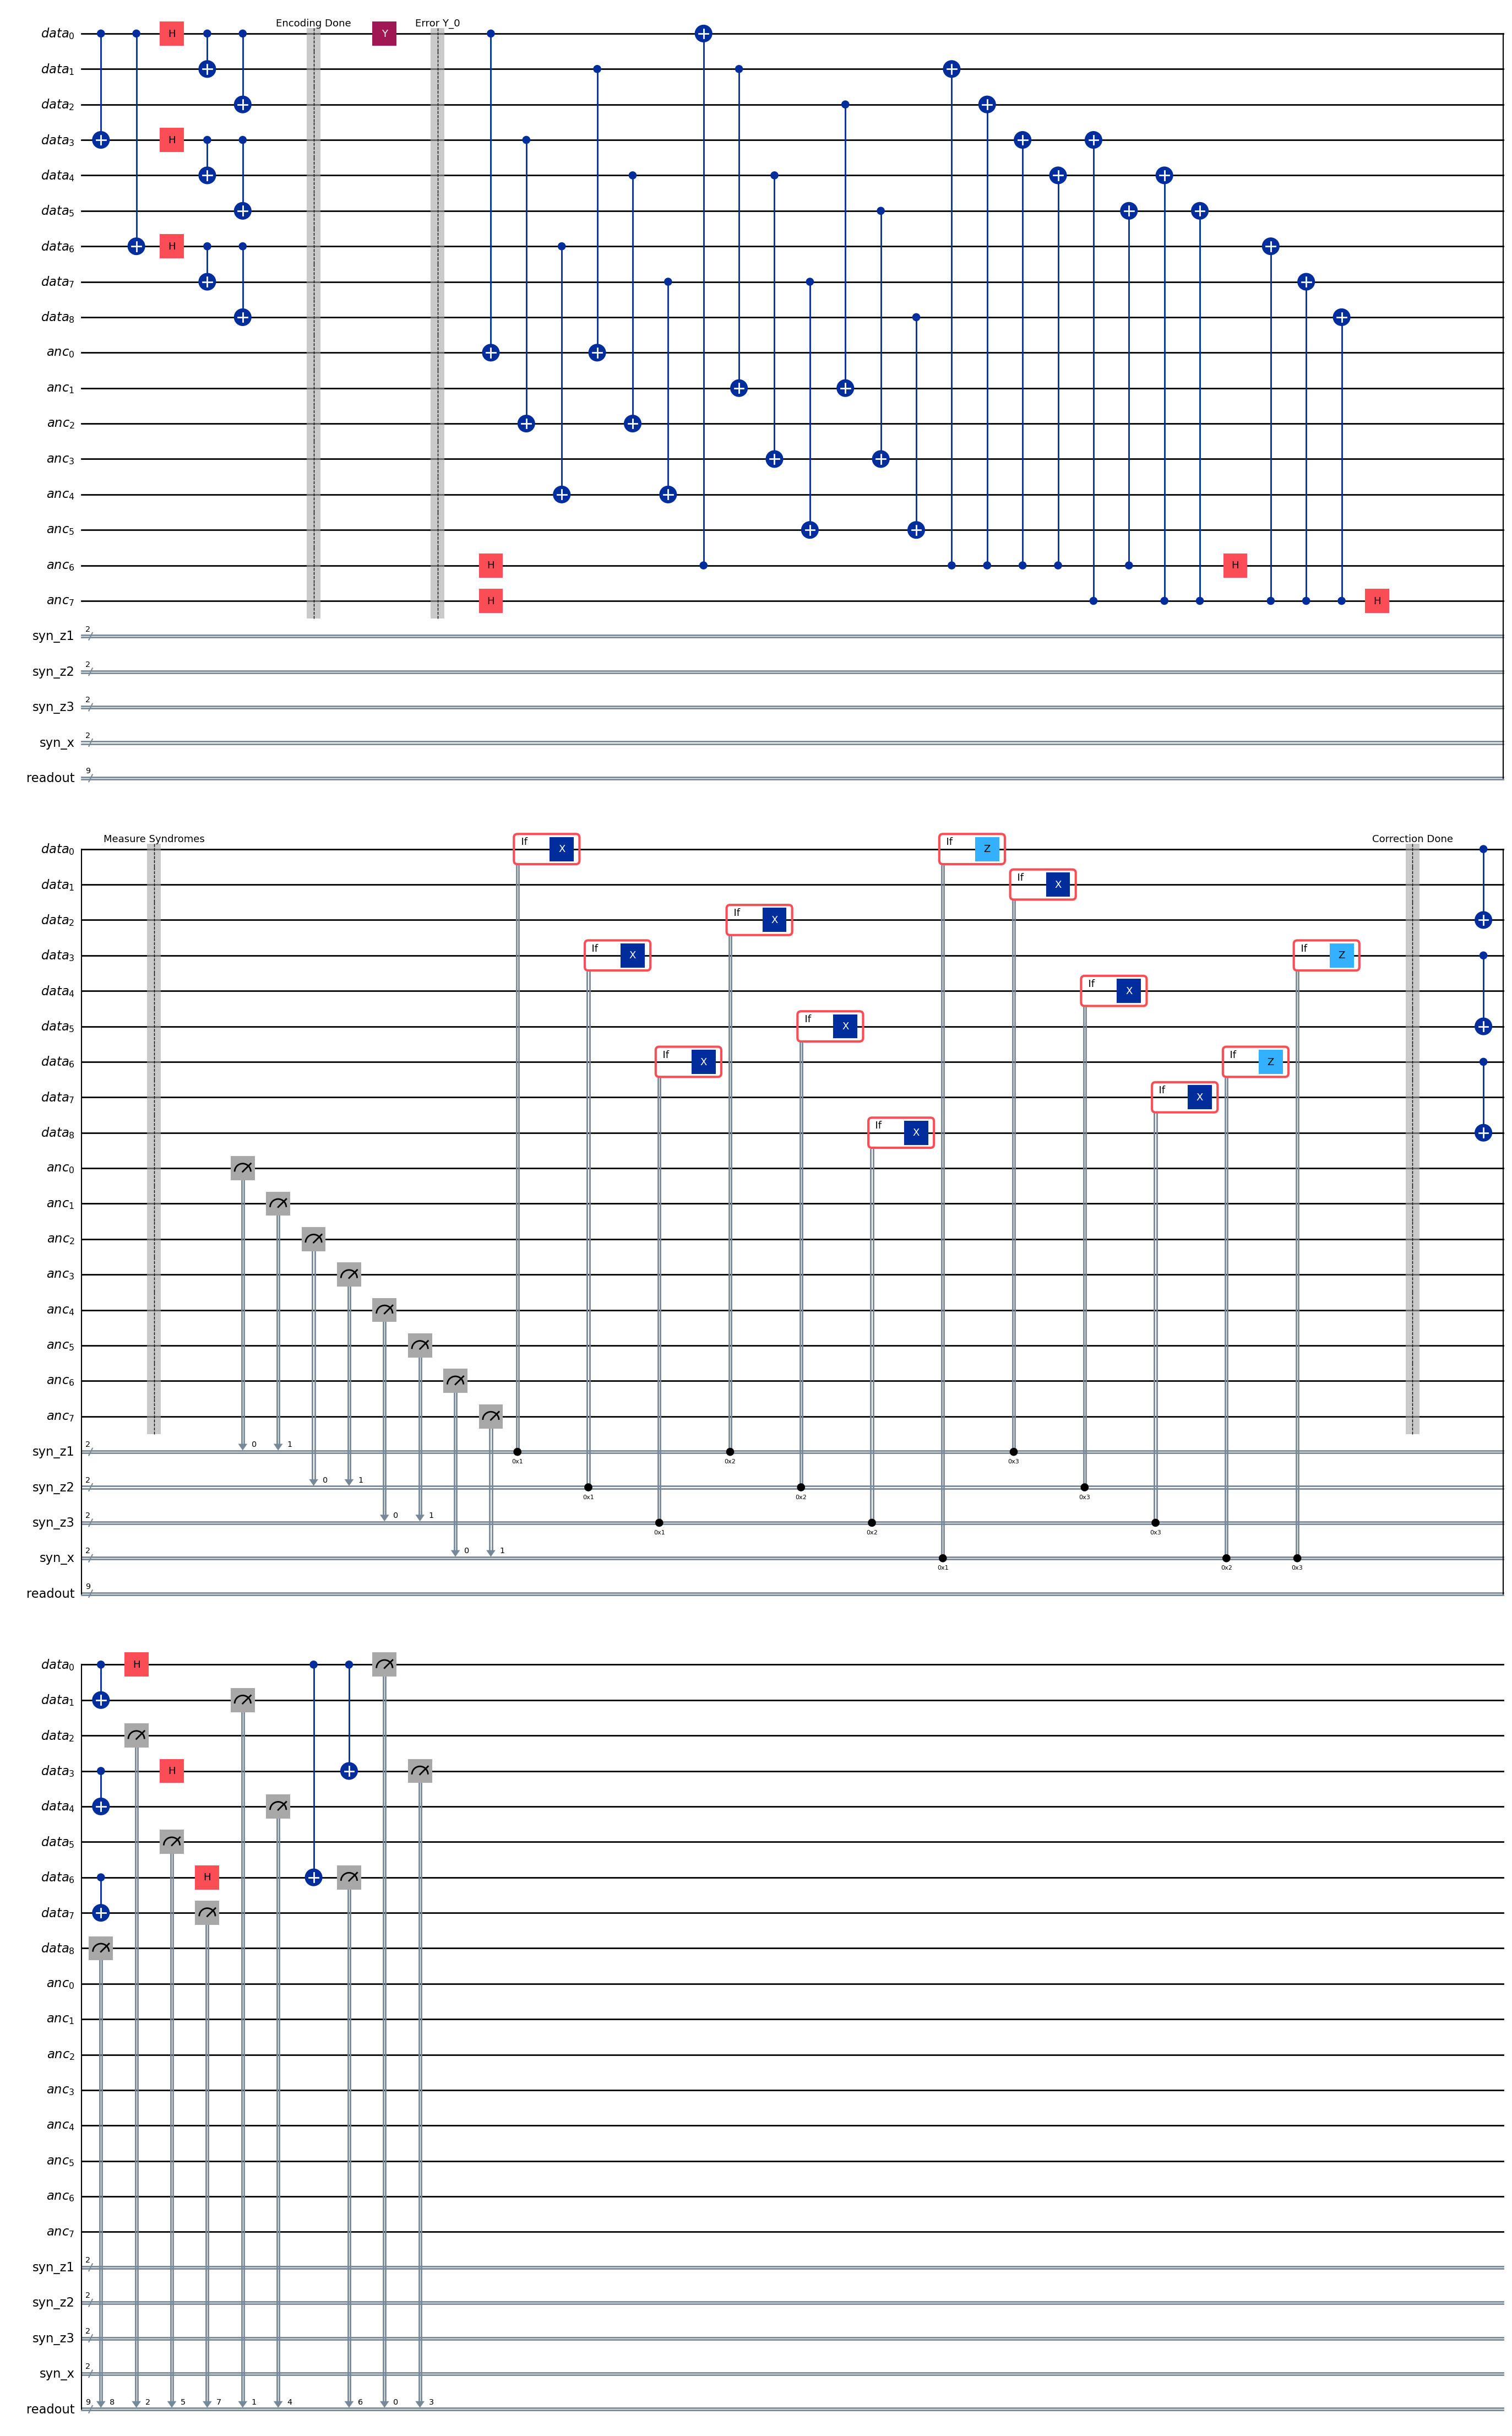

In [3]:
# Running a Test Case (Y-Error)
# Use a Y-error because it is a combined X and Z error
# The code should detect both X and Z errors and correct both of them

shor = ShorCode()
shor.encode()

# Inject Y error on Qubit 0 (Topmost qubit)
print("Injecting Y error on Qubit 0...")
shor.inject_error('Y', 0)

shor.measure_syndromes()
shor.apply_correction()
circuit = shor.decode_and_verify()

# Run Simulation
backend = AerSimulator()
result = backend.run(circuit, shots=1000).result()
counts = result.get_counts()

# Look for the 'readout' register (the 9 bits on the left)
# A successful correction means the data register is '000000000'
print("\nSimulation Results (Raw Counts):")
print(counts)

# Calculate Success Rate
success_count = 0
for outcome, count in counts.items():
    # outcome string format: "readout syn_x syn_z3 syn_z2 syn_z1"
    # We only care about the readout part (first 9 bits)
    readout_part = outcome.split(" ")[0]
    if readout_part == '000000000':
        success_count += count

print(f"\nCorrected {success_count}/1000 shots.")
print(f"Fidelity: {success_count/1000:.4f}")

# Draw the circuit to verify structure
circuit.draw('mpl', fold=40)


## 4. Simulation & Performance Analysis

To validate the implementation of the Shor $[[9,1,3]]$ code, we conduct a **Monte Carlo simulation** to measure its logical error rate ($P_L$) under a standard noise model. We then compare these empirical results against the theoretical prediction for a code that corrects single-qubit errors.

### 4.1 Methodology
The simulation proceeds through the following steps for a range of physical error rates $p \in [0, 0.05]$:

1.  **Initialization:** The system is initialized in the logical $|0\rangle_L$ state.
2.  **Noise Injection:** We apply an **independent depolarizing noise model**. For every physical qubit $q_i$, an error is injected with probability $p$. If an error occurs, it is randomly chosen as $X$, $Y$, or $Z$ with equal probability ($p/3$).
3.  **Error Correction:** The full syndrome extraction circuit is executed (using 8 ancilla qubits), and corrections are applied based on the measured syndromes.
4.  **Verification:** The state is decoded back to a single physical qubit. If the final state is $|0\rangle$, the correction is deemed successful. If the state is $|1\rangle$, a logical error has occurred.

### 4.2 Theoretical Benchmark
Since the Shor code has distance $d=3$, it can correct any single-qubit error (weight $w=1$). It fails if **two or more** qubits suffer errors (assuming the decoder is optimal for weight-1 errors).

The theoretical probability of failure $P_{fail}$ is given by the probability that 2 or more independent errors occur in a block of 9:

$$P_{theory} = 1 - \underbrace{(1-p)^9}_{\text{No errors}} - \underbrace{9p(1-p)^8}_{\text{Exactly 1 error}}$$



We expect our simulated results (Red Dots) to closely track this theoretical curve (Blue Line), demonstrating the **Pseudo-Threshold** behavior where the code becomes effective below $p \approx 0.03$.

In [4]:
# Define Monte-Carlo Simulation Functions

def apply_random_noise(shor_instance, p):
    """
    Applies independent depolarizing noise to all 9 data qubits
    Each qubit has a probability 'p' of suffering an X, Y, or Z error
    """
    # Iterate through all 9 qubits
    for qubit_idx in range(9):
        if np.random.random() < p:
            # If an error occurs, pick one of X, Y, Z uniformly
            error_type = np.random.choice(['X', 'Y', 'Z'])
            shor_instance.inject_error(error_type, qubit_idx)

def run_performance_simulation(p_values, shots_per_point=1000):
    """
    Runs the full Shor code cycle for a list of physical error rates
    Returns the calculated logical error rates
    """
    logical_error_rates = []

    # Use a clean simulator for batch processing
    backend = AerSimulator()

    print(f"Starting simulation for {len(p_values)} points...")

    for p in p_values:
        failures = 0

        # NOTE: For true Monte Carlo, we should ideally rebuild the circuit
        # for every single shot to get unique random noise instances.
        # To speed this up for the notebook, here we run 'shots_per_point' individual circuits.
        # This list will hold all our test circuits for this specific 'p'
        circuits = []

        for _ in range(shots_per_point):
            # New Instance
            shor = ShorCode()
            shor.encode()

            # Apply Random Noise
            apply_random_noise(shor, p)

            # Detect & Correct
            shor.measure_syndromes()
            shor.apply_correction()

            # Decode
            qc = shor.decode_and_verify()
            circuits.append(qc)

        # Run all circuits for this probability in one batch
        # optimization_level=0 ensures our error injection isn't optimized away
        result = backend.run(circuits, shots=1, optimization_level=0).result()

        # Analyze results
        # We get a list of counts, one for each circuit
        for i in range(shots_per_point):
            counts = result.get_counts(i)
            # Check if readout is '000000000'
            # Outcome format: "readout syn_x ..."
            outcome = list(counts.keys())[0]
            readout = outcome.split(" ")[0]

            if readout != '000000000':
                failures += 1

        p_logical = failures / shots_per_point
        logical_error_rates.append(p_logical)
        print(f"p={p:.4f} -> P_Logical={p_logical:.4f}")

    return logical_error_rates


Starting simulation for 10 points...
p=0.0010 -> P_Logical=0.0000
p=0.0015 -> P_Logical=0.0000
p=0.0024 -> P_Logical=0.0001
p=0.0037 -> P_Logical=0.0002
p=0.0057 -> P_Logical=0.0004
p=0.0088 -> P_Logical=0.0010
p=0.0136 -> P_Logical=0.0020
p=0.0210 -> P_Logical=0.0051
p=0.0324 -> P_Logical=0.0094
p=0.0500 -> P_Logical=0.0261


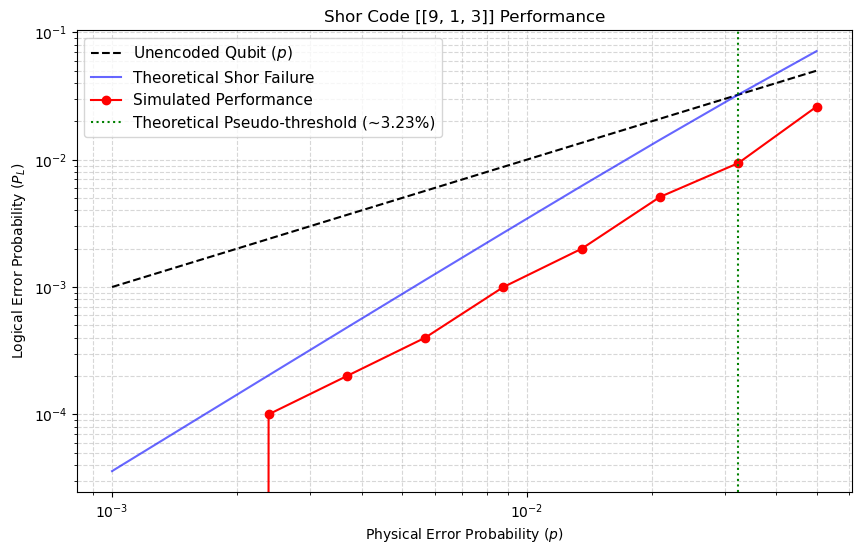

In [5]:
# Execute Simulation and Plot
import matplotlib.pyplot as plt

# Define the range of physical error rates to test
# Focus on 10^-3 to 0.05. np.log10(0.05) is roughly -1.3
p_phys_samples = np.logspace(-3, np.log10(0.05), 10)

# Run the simulation
p_log_simulated = run_performance_simulation(p_phys_samples, shots_per_point=10000)

# Calculate Theoretical Curve
# The probability that 2 or more qubits fail (since Shor corrects 1)
# P_fail = 1 - P(0 errors) - P(1 error)
p_theoretical = 1 - (1 - p_phys_samples)**9 - 9 * p_phys_samples * (1 - p_phys_samples)**8

def shor_theoretical_diff(p):
    """The difference between the theoretical bound and the unencoded baseline for n=9"""
    return (1 - (1 - p)**9 - 9 * p * (1 - p)**8) - p

# fsolve finds where the difference is 0. We give it an initial guess of 0.03
exact_shor_crossover = fsolve(shor_theoretical_diff, 0.03)[0]

# Plotting
plt.figure(figsize=(10, 6))

# Unencoded Qubit (Baseline y=x)
plt.loglog(p_phys_samples, p_phys_samples, 'k--', label='Unencoded Qubit ($p$)')

# Theoretical Curve
plt.loglog(p_phys_samples, p_theoretical, 'b-', alpha=0.6, label='Theoretical Shor Failure')

# Simulated Data
plt.loglog(p_phys_samples, p_log_simulated, 'ro-', label='Simulated Performance')

# Aesthetics
plt.title('Shor Code [[9, 1, 3]] Performance')
plt.xlabel('Physical Error Probability ($p$)')
plt.ylabel('Logical Error Probability ($P_L$)')
plt.grid(True, which="both", linestyle='--', alpha=0.5)

# Mark the Break-even point
plt.axvline(x=exact_shor_crossover, color='green', linestyle=':',
            label=f'Theoretical Pseudo-threshold (~{exact_shor_crossover*100:.2f}%)')

plt.legend(fontsize=11)

plt.show()
